# Gaussian photon scattering

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is selected in the parameter cell (currently `flat`).
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).

Positive, negative and zero-momentum populations are reported directly. The initial packet may contain all three components; these populations alone are not asymptotic scattering coefficients.

With the imposed phases, the interaction coordinate on the spatial graph is -x_tls (see the derivation in the documentation).


In [1]:
from pathlib import Path
import sys

# Works whether the kernel starts at the repository root or inside notebooks/.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataclasses import replace
import numpy as np
import pandas as pd
from IPython.display import display

# Keep small populations and norm drift visible; stored values retain full precision.
pd.set_option('display.float_format', '{:.9g}'.format)
import matplotlib.pyplot as plt
from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time
from experiment.scattering import run_scattering, plot_scattering

## Parameters


In [2]:
CTRL_M_EXPLICIT = False
M = 5                         # Must be odd; k=0 is included.

cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 3.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 
              'D': 1.0, 
              'L': 20*np.pi,
              'x_tls': 0.0, 
              'coupling': 'flat', 
              'initial_state': 'g'}

param_photon = {'k_0': 1.0, 
                'sigma_k': 0.1, 
                'x_0': -5*np.pi,
                'state': 'number', 
                'n': 1, 
                'alpha': 1.0}

param_time_evol = {'T': 10*np.pi, 'dt': 0.1, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 2
truncation = 'full+totalcap'
RWA = True

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimates and simulation

The tables are stored as DataFrames. Memory estimates exclude sparse matrices, basis/Python objects, solver workspace and plots; `feasible` is a heuristic.


In [3]:
estimate = estimate_config(config, print_report=False)
grid_table, resource_table = estimate['grid_table'], estimate['resource_table']
display(grid_table, resource_table)
# Review the feasible column before choosing to run a large simulation.

,L,delta_k,control,requested_M,requested_IR,requested_UV,n_modes,k_min,k_max,ir_effective,uv_effective,smallest_nonzero_k,zero_present,radial_cutoffs_exact,equivalent_M
grid,,,,,,,,,,,,,,,
base,62.8318531,0.1,IR/UV,<NA>,0,3,61,-3,3,0,3,0.1,True,True,61
selected,62.8318531,0.1,IR/UV,<NA>,0,3,61,-3,3,0,3,0.1,True,True,61


,basis,n_max,store_state,n_modes,dimension,n_times,ket_gib,history_gib,retained_vectors_gib,hamiltonian_nnz_bound,feasible
0,full+totalcap,2,True,61,3906,316,5.82039356e-05,0.0183924437,0.0367848873,480438,True


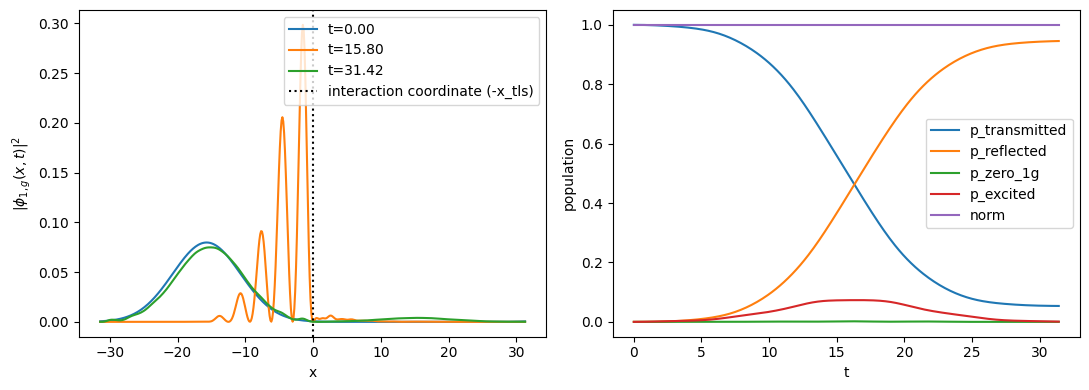

,initial,final
observable,,
time,0,31.4159265
norm,1,0.999999699
p_excited,0,0.000869265714
p_transmitted,1,0.0535713536
p_reflected,2.11884071e-27,0.945532483
p_zero_1g,7.69459859e-23,2.65973726e-05
p_0_photon,0,0.000869265714
p_1_photon,1,0.999130434
p_2_photon,0,0


In [4]:
experiment = run_scattering(param_photon, param_atom, param_time_evol, cutoffs,
                            n_max=n_max, truncation=truncation, RWA=RWA,
                            CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)
fig = plot_scattering(experiment)
plt.show()
observable_history = experiment.observables_dataframe()
observable_summary = experiment.observables_dataframe(summary=True)
display(observable_summary)

## Additional diagnostics


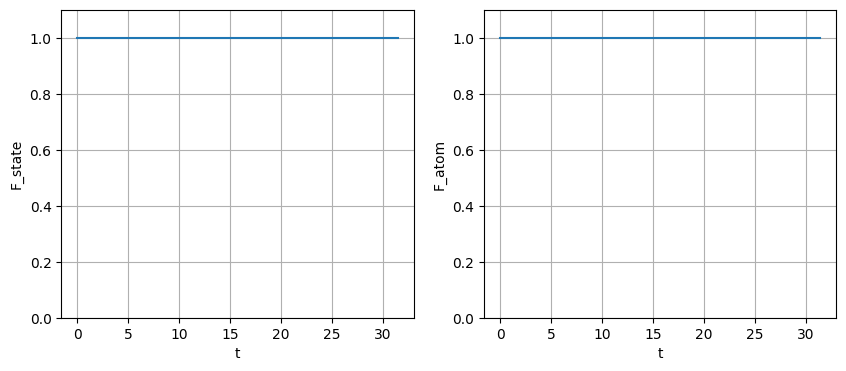

,initial,final,time_mean
fidelity,,,
F_state,1,1,1
F_atom,1,1,1


In [5]:
candidate = run_scattering(param_photon, param_atom, param_time_evol, cutoffs,
                           n_max=n_max, truncation='truncated', RWA=RWA,
                           CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)
F = fidelities_over_time(candidate, experiment)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ('F_state', 'F_atom')):
    ax.plot(experiment.times, F[name])
    ax.set(xlabel='t', ylabel=name)
    ax.set_ylim([0,1.1])
    ax.grid()
plt.show()

fidelity_history = pd.DataFrame(F, index=pd.Index(experiment.times, name='time'))
fidelity_summary = pd.DataFrame({
    'initial': {name: values[0] for name, values in F.items()},
    'final': {name: values[-1] for name, values in F.items()},
    'time_mean': {name: np.mean(values) for name, values in F.items()},
}).rename_axis('fidelity')
display(fidelity_summary)
